# Logistics Data Analysis Using Python

## Project Overview

This project analyzes logistics shipment data to understand delivery performance, delays, carrier performance, warehouse performance, destination performance, transportation cost, and transit time.

### Business Objectives

- Measure overall shipment and delivery performance.
- Analyze shipment delays.
- Compare carrier performance.
- Compare warehouse performance.
- Analyze destination-level performance.
- Understand shipping cost and shipment weight.
- Analyze the relationship between distance and transit time.
- Identify operational areas that require further investigation.

### Tools & Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset

The analysis uses a logistics shipment dataset containing shipment, warehouse, destination, carrier, date, weight, cost, status, distance, and transit-time information.

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\koush\Downloads\logistics_shipments_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.head())

Dataset loaded successfully!
Rows: 2000
Columns: 11
  Shipment_ID Origin_Warehouse    Destination Carrier Shipment_Date  \
0     SH10000    Warehouse_MIA  San Francisco     UPS    2023-10-02   
1     SH10001    Warehouse_MIA        Atlanta     DHL    2023-12-06   
2     SH10002     Warehouse_LA        Houston     DHL    2023-09-18   
3     SH10003    Warehouse_BOS        Seattle  OnTrac    2023-01-26   
4     SH10004     Warehouse_SF         Dallas  OnTrac    2023-06-03   

  Delivery_Date  Weight_kg    Cost     Status  Distance_miles  Transit_Days  
0    2023-10-04       25.7   67.46  Delivered             291             2  
1    2023-12-09       38.9  268.85  Delivered            1225             3  
2    2023-09-20       37.2   74.35  Delivered             220             2  
3    2023-02-04       42.6  187.04  Delivered            1156             9  
4    2023-06-06        7.9  120.01  Delivered            1017             3  


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 11


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   str    
 1   Origin_Warehouse  2000 non-null   str    
 2   Destination       2000 non-null   str    
 3   Carrier           2000 non-null   str    
 4   Shipment_Date     2000 non-null   str    
 5   Delivery_Date     1968 non-null   str    
 6   Weight_kg         2000 non-null   float64
 7   Cost              1959 non-null   float64
 8   Status            2000 non-null   str    
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 294.6 KB


In [4]:
print(df.isnull().sum())

Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              0
Shipment_Date        0
Delivery_Date       32
Weight_kg            0
Cost                41
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64


In [5]:
df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])

print(df[["Shipment_Date", "Delivery_Date"]].head())

  Shipment_Date Delivery_Date
0    2023-10-02    2023-10-04
1    2023-12-06    2023-12-09
2    2023-09-18    2023-09-20
3    2023-01-26    2023-02-04
4    2023-06-03    2023-06-06


In [6]:
print(df["Shipment_Date"].dtype)
print(df["Delivery_Date"].dtype)

datetime64[us]
datetime64[us]


In [7]:
df["Calculated_Transit_Days"] = (
    df["Delivery_Date"] - df["Shipment_Date"]
).dt.days

print(df[[
    "Shipment_ID",
    "Shipment_Date",
    "Delivery_Date",
    "Transit_Days",
    "Calculated_Transit_Days"
]].head(10))

  Shipment_ID Shipment_Date Delivery_Date  Transit_Days  \
0     SH10000    2023-10-02    2023-10-04             2   
1     SH10001    2023-12-06    2023-12-09             3   
2     SH10002    2023-09-18    2023-09-20             2   
3     SH10003    2023-01-26    2023-02-04             9   
4     SH10004    2023-06-03    2023-06-06             3   
5     SH10005    2023-09-13    2023-09-16             3   
6     SH10006    2023-10-19    2023-10-23             4   
7     SH10007    2023-02-27    2023-03-08             9   
8     SH10008    2023-11-24    2023-12-01             7   
9     SH10009    2023-01-19    2023-01-21             2   

   Calculated_Transit_Days  
0                      2.0  
1                      3.0  
2                      2.0  
3                      9.0  
4                      3.0  
5                      3.0  
6                      4.0  
7                      9.0  
8                      7.0  
9                      2.0  


In [8]:
print(
    "Matching records:",
    (df["Transit_Days"] == df["Calculated_Transit_Days"]).sum()
)

print(
    "Total records:",
    len(df)
)

Matching records: 1759
Total records: 2000


In [9]:
status_count = df["Status"].value_counts()

print(status_count)

Status
Delivered     1648
Delayed        199
In Transit      76
Lost            45
Returned        32
Name: count, dtype: int64


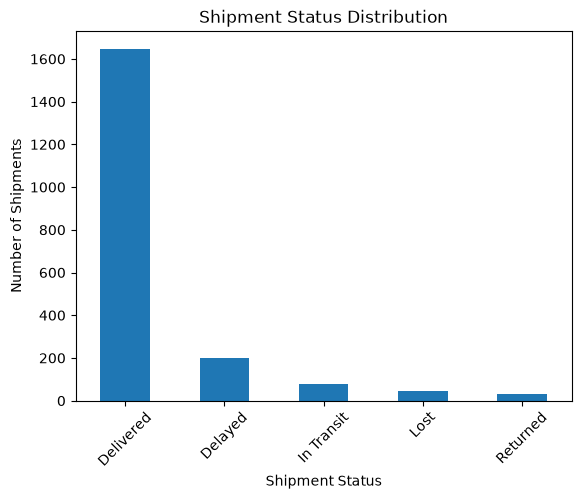

In [10]:
import matplotlib.pyplot as plt
status_count.plot(kind="bar")

plt.title("Shipment Status Distribution")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.show()

In [11]:
total_shipments = len(df)

delivered_shipments = (df["Status"] == "Delivered").sum()

delivery_rate = (delivered_shipments / total_shipments) * 100

print("Total Shipments:", total_shipments)
print("Delivered Shipments:", delivered_shipments)
print("Delivery Rate:", round(delivery_rate, 2), "%")

Total Shipments: 2000
Delivered Shipments: 1648
Delivery Rate: 82.4 %


In [12]:
delayed_shipments = (df["Status"] == "Delayed").sum()

delay_rate = (delayed_shipments / total_shipments) * 100

print("Delayed Shipments:", delayed_shipments)
print("Delay Rate:", round(delay_rate, 2), "%")

Delayed Shipments: 199
Delay Rate: 9.95 %


In [13]:
average_transit_days = df["Transit_Days"].mean()

print("Average Transit Days:", round(average_transit_days, 2))

Average Transit Days: 4.18


In [14]:
average_cost = df["Cost"].mean()

print("Average Shipping Cost:", round(average_cost, 2))

Average Shipping Cost: 205.16


In [15]:
carrier_count = df["Carrier"].value_counts()

print(carrier_count)

Carrier
LaserShip           303
OnTrac              299
FedEx               295
USPS                292
DHL                 281
Amazon Logistics    274
UPS                 256
Name: count, dtype: int64


In [16]:
average_transit_by_carrier = df.groupby("Carrier")["Transit_Days"].mean()

print(average_transit_by_carrier.round(2))

Carrier
Amazon Logistics    4.32
DHL                 4.27
FedEx               4.30
LaserShip           4.04
OnTrac              4.12
UPS                 4.20
USPS                4.05
Name: Transit_Days, dtype: float64


In [17]:
carrier_delay_rate = df.groupby("Carrier")["Status"].apply(
    lambda x: (x == "Delayed").mean() * 100
)

print(carrier_delay_rate.round(2))

Carrier
Amazon Logistics    12.41
DHL                 13.88
FedEx                8.81
LaserShip            8.58
OnTrac               9.70
UPS                  9.38
USPS                 7.19
Name: Status, dtype: float64


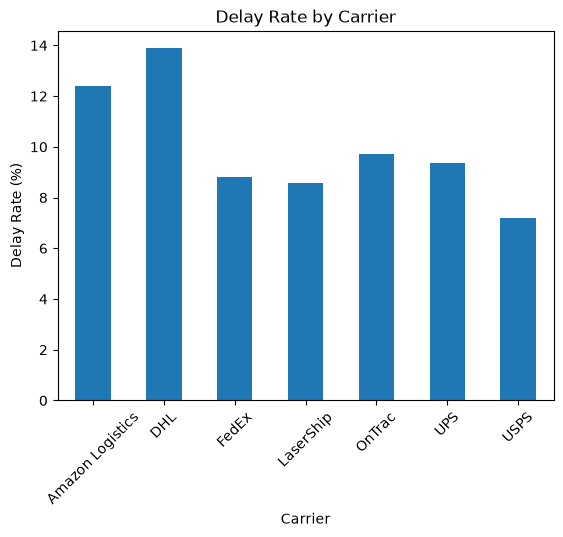

In [18]:
import matplotlib.pyplot as plt
carrier_delay_rate.plot(kind="bar")

plt.title("Delay Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [19]:
warehouse_count = df["Origin_Warehouse"].value_counts()

print(warehouse_count)

Origin_Warehouse
Warehouse_LA     220
Warehouse_SF     215
Warehouse_HOU    212
Warehouse_ATL    207
Warehouse_MIA    201
Warehouse_CHI    197
Warehouse_DEN    196
Warehouse_BOS    192
Warehouse_SEA    190
Warehouse_NYC    170
Name: count, dtype: int64


In [20]:
average_transit_by_warehouse = df.groupby(
    "Origin_Warehouse"
)["Transit_Days"].mean()

print(average_transit_by_warehouse.round(2))

Origin_Warehouse
Warehouse_ATL    4.12
Warehouse_BOS    4.50
Warehouse_CHI    3.96
Warehouse_DEN    4.02
Warehouse_HOU    4.17
Warehouse_LA     4.15
Warehouse_MIA    4.23
Warehouse_NYC    4.12
Warehouse_SEA    4.39
Warehouse_SF     4.18
Name: Transit_Days, dtype: float64


In [21]:
warehouse_delay_rate = df.groupby(
    "Origin_Warehouse"
)["Status"].apply(
    lambda x: (x == "Delayed").mean() * 100
)

print(warehouse_delay_rate.round(2))

Origin_Warehouse
Warehouse_ATL    10.63
Warehouse_BOS     8.85
Warehouse_CHI    10.66
Warehouse_DEN     8.16
Warehouse_HOU    11.79
Warehouse_LA     10.45
Warehouse_MIA    11.44
Warehouse_NYC     5.88
Warehouse_SEA     9.47
Warehouse_SF     11.16
Name: Status, dtype: float64


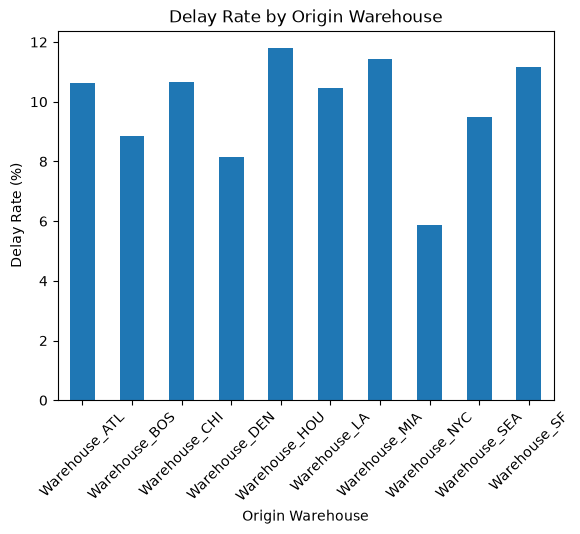

In [22]:
import matplotlib.pyplot as plt

warehouse_delay_rate.plot(kind="bar")

plt.title("Delay Rate by Origin Warehouse")
plt.xlabel("Origin Warehouse")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [23]:
destination_count = df["Destination"].value_counts()

print(destination_count)

Destination
Chicago          154
Phoenix          148
Minneapolis      148
Portland         146
Denver           142
Detroit          141
Dallas           137
Atlanta          133
San Francisco    129
Los Angeles      127
Houston          126
Miami            123
Boston           119
New York         117
Seattle          110
Name: count, dtype: int64


In [24]:
average_transit_by_destination = df.groupby(
    "Destination"
)["Transit_Days"].mean()

print(average_transit_by_destination.round(2))

Destination
Atlanta          4.08
Boston           4.58
Chicago          4.25
Dallas           4.12
Denver           3.75
Detroit          4.00
Houston          4.21
Los Angeles      4.21
Miami            4.26
Minneapolis      4.17
New York         4.15
Phoenix          4.10
Portland         4.21
San Francisco    4.40
Seattle          4.37
Name: Transit_Days, dtype: float64


In [25]:
destination_delay_rate = df.groupby(
    "Destination"
)["Status"].apply(
    lambda x: (x == "Delayed").mean() * 100
)

print(destination_delay_rate.round(2))

Destination
Atlanta           8.27
Boston           16.81
Chicago           9.09
Dallas            9.49
Denver            8.45
Detroit          14.18
Houston           8.73
Los Angeles       8.66
Miami             6.50
Minneapolis       9.46
New York         11.11
Phoenix          11.49
Portland          8.22
San Francisco     9.30
Seattle          10.00
Name: Status, dtype: float64


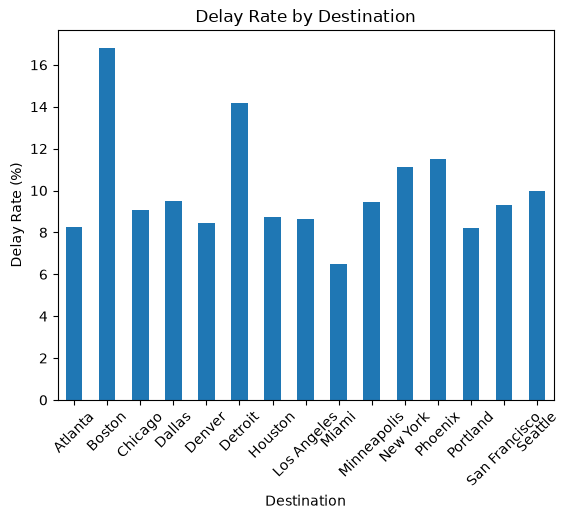

In [26]:
import matplotlib.pyplot as plt
destination_delay_rate.plot(kind="bar")

plt.title("Delay Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [27]:
print("Average Weight:", round(df["Weight_kg"].mean(), 2), "kg")
print("Average Cost:", round(df["Cost"].mean(), 2))
print("Minimum Cost:", round(df["Cost"].min(), 2))
print("Maximum Cost:", round(df["Cost"].max(), 2))

Average Weight: 30.18 kg
Average Cost: 205.16
Minimum Cost: 17.89
Maximum Cost: 6562.21


In [28]:
average_cost_by_carrier = df.groupby("Carrier")["Cost"].mean()

print(average_cost_by_carrier.round(2))

Carrier
Amazon Logistics    193.91
DHL                 222.13
FedEx               217.97
LaserShip           207.86
OnTrac              184.60
UPS                 229.71
USPS                182.66
Name: Cost, dtype: float64


In [29]:
correlation = df["Weight_kg"].corr(df["Cost"])

print("Correlation between Weight and Cost:", round(correlation, 2))

Correlation between Weight and Cost: 0.02


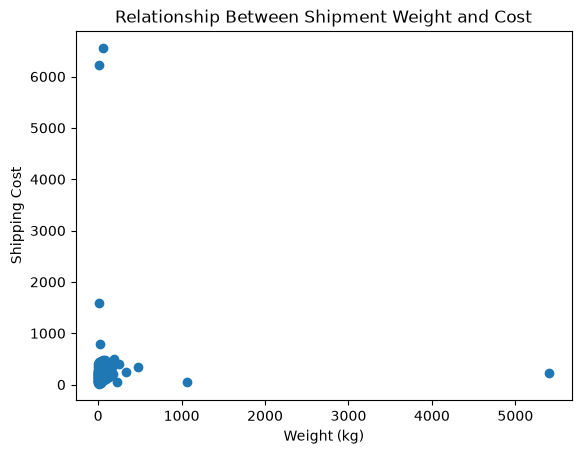

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df["Weight_kg"], df["Cost"])

plt.title("Relationship Between Shipment Weight and Cost")
plt.xlabel("Weight (kg)")
plt.ylabel("Shipping Cost")

plt.show()

In [31]:
distance_transit_correlation = df["Distance_miles"].corr(
    df["Transit_Days"]
)

print(
    "Correlation between Distance and Transit Days:",
    round(distance_transit_correlation, 2)
)

Correlation between Distance and Transit Days: 0.76


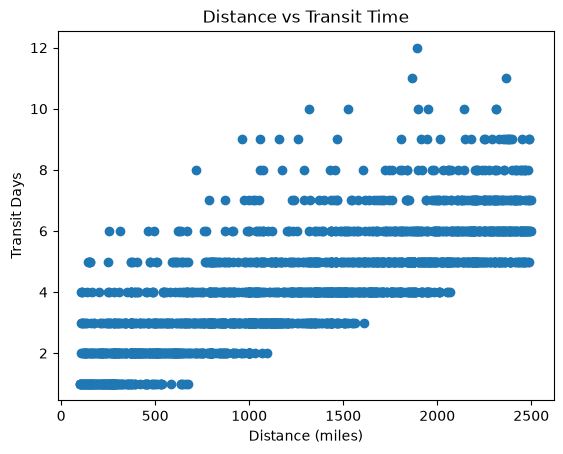

In [32]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Distance_miles"],
    df["Transit_Days"]
)

plt.title("Distance vs Transit Time")
plt.xlabel("Distance (miles)")
plt.ylabel("Transit Days")

plt.show()

In [33]:
df["Shipment_Month"] = df["Shipment_Date"].dt.month

print(df[["Shipment_Date", "Shipment_Month"]].head())

  Shipment_Date  Shipment_Month
0    2023-10-02              10
1    2023-12-06              12
2    2023-09-18               9
3    2023-01-26               1
4    2023-06-03               6


In [34]:
monthly_shipments = df["Shipment_Month"].value_counts().sort_index()

print(monthly_shipments)

Shipment_Month
1     163
2     139
3     167
4     162
5     173
6     164
7     166
8     182
9     163
10    173
11    178
12    170
Name: count, dtype: int64


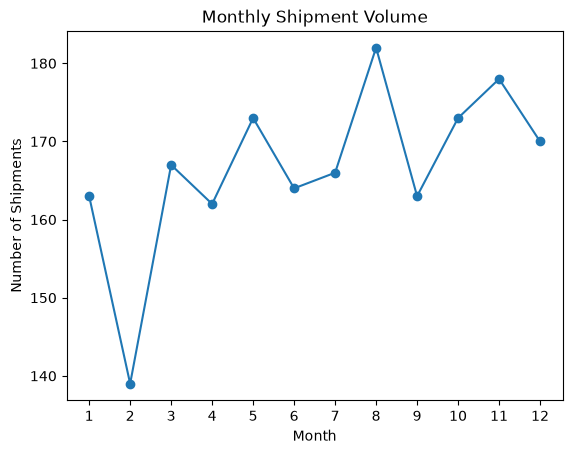

In [35]:
import matplotlib.pyplot as plt

monthly_shipments.plot(kind="line", marker="o")

plt.title("Monthly Shipment Volume")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.xticks(range(1, 13))

plt.show()

In [36]:
monthly_delay_rate = df.groupby("Shipment_Month")["Status"].apply(
    lambda x: (x == "Delayed").mean() * 100
)

print(monthly_delay_rate.round(2))

Shipment_Month
1      7.36
2     12.23
3     11.38
4      9.88
5      8.67
6      9.15
7      9.64
8      8.79
9      9.82
10     9.83
11     8.99
12    14.12
Name: Status, dtype: float64


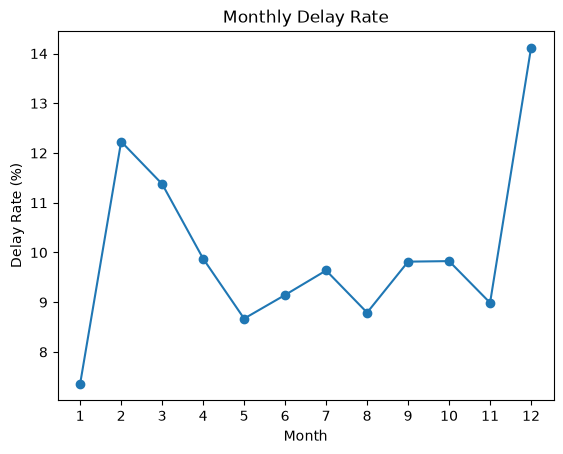

In [37]:
import matplotlib.pyplot as plt

monthly_delay_rate.plot(kind="line", marker="o")

plt.title("Monthly Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(1, 13))

plt.show()

In [38]:
highest_cost_shipments = df.sort_values(
    by="Cost",
    ascending=False
)

print(
    highest_cost_shipments[
        [
            "Shipment_ID",
            "Carrier",
            "Origin_Warehouse",
            "Destination",
            "Weight_kg",
            "Distance_miles",
            "Cost",
            "Status"
        ]
    ].head(10)
)

     Shipment_ID    Carrier Origin_Warehouse    Destination  Weight_kg  \
1105     SH11105  LaserShip     Warehouse_LA  San Francisco       54.6   
922      SH10922        UPS    Warehouse_HOU        Detroit       12.8   
1912     SH11912        UPS     Warehouse_LA       Portland       14.6   
1149     SH11149       USPS    Warehouse_SEA        Chicago       19.0   
1552     SH11552     OnTrac    Warehouse_SEA         Boston      184.3   
517      SH10517       USPS    Warehouse_HOU         Boston       80.0   
366      SH10366      FedEx    Warehouse_BOS         Boston       55.1   
303      SH10303        DHL    Warehouse_DEN         Boston       30.5   
1938     SH11938      FedEx     Warehouse_LA        Detroit       61.7   
1539     SH11539      FedEx     Warehouse_LA    Minneapolis       36.3   

      Distance_miles     Cost     Status  
1105            1942  6562.21  Delivered  
922             2490  6229.12  Delivered  
1912            2187  1597.99  Delivered  
1149         

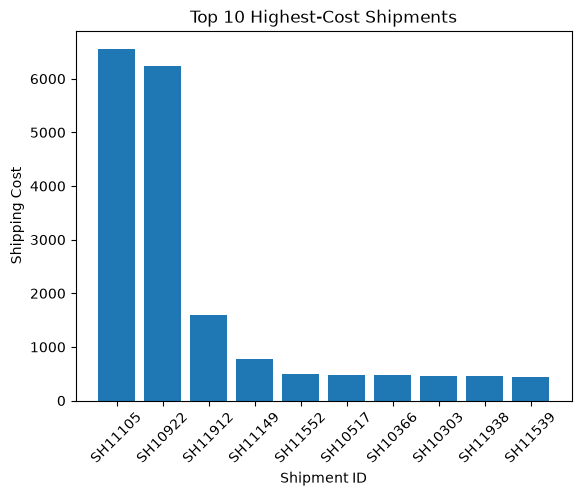

In [39]:
top_10_cost = highest_cost_shipments.head(10)

plt.bar(
    top_10_cost["Shipment_ID"],
    top_10_cost["Cost"]
)

plt.title("Top 10 Highest-Cost Shipments")
plt.xlabel("Shipment ID")
plt.ylabel("Shipping Cost")
plt.xticks(rotation=45)

plt.show()

In [40]:
longest_transit_shipments = df.sort_values(
    by="Transit_Days",
    ascending=False
)

print(
    longest_transit_shipments[
        [
            "Shipment_ID",
            "Carrier",
            "Origin_Warehouse",
            "Destination",
            "Distance_miles",
            "Transit_Days",
            "Cost",
            "Status"
        ]
    ].head(10)
)

     Shipment_ID           Carrier Origin_Warehouse  Destination  \
1093     SH11093  Amazon Logistics    Warehouse_BOS     Portland   
1733     SH11733  Amazon Logistics    Warehouse_HOU      Phoenix   
103      SH10103  Amazon Logistics    Warehouse_BOS     New York   
1394     SH11394             FedEx    Warehouse_MIA       Boston   
1372     SH11372              USPS    Warehouse_MIA      Houston   
602      SH10602  Amazon Logistics    Warehouse_HOU       Dallas   
581      SH10581             FedEx    Warehouse_MIA      Chicago   
318      SH10318            OnTrac    Warehouse_HOU  Los Angeles   
960      SH10960               DHL    Warehouse_NYC       Dallas   
346      SH10346             FedEx     Warehouse_SF      Houston   

      Distance_miles  Transit_Days    Cost      Status  
1093            1895            12  226.92   Delivered  
1733            1865            11  320.20   Delivered  
103             2366            11  283.56   Delivered  
1394            1525   

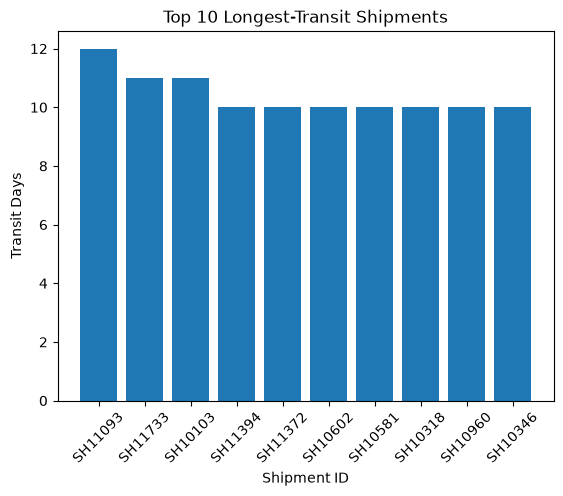

In [41]:
top_10_transit = longest_transit_shipments.head(10)

plt.bar(
    top_10_transit["Shipment_ID"],
    top_10_transit["Transit_Days"]
)

plt.title("Top 10 Longest-Transit Shipments")
plt.xlabel("Shipment ID")
plt.ylabel("Transit Days")
plt.xticks(rotation=45)

plt.show()

In [42]:
average_cost_by_carrier = df.groupby("Carrier")["Cost"].mean()

print(average_cost_by_carrier.round(2))

Carrier
Amazon Logistics    193.91
DHL                 222.13
FedEx               217.97
LaserShip           207.86
OnTrac              184.60
UPS                 229.71
USPS                182.66
Name: Cost, dtype: float64


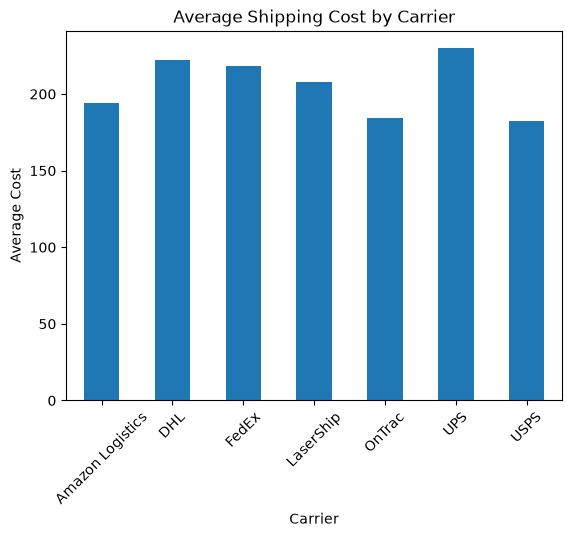

In [43]:
average_cost_by_carrier.plot(kind="bar")

plt.title("Average Shipping Cost by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)

plt.show()

In [44]:
df["Cost_per_Mile"] = df["Cost"] / df["Distance_miles"]

print(
    df[
        ["Shipment_ID", "Distance_miles", "Cost", "Cost_per_Mile"]
    ].head(10)
)

  Shipment_ID  Distance_miles    Cost  Cost_per_Mile
0     SH10000             291   67.46       0.231821
1     SH10001            1225  268.85       0.219469
2     SH10002             220   74.35       0.337955
3     SH10003            1156  187.04       0.161799
4     SH10004            1017  120.01       0.118004
5     SH10005             898  143.26       0.159532
6     SH10006            1522  225.23       0.147983
7     SH10007            2013  281.23       0.139707
8     SH10008            2072  341.93       0.165024
9     SH10009             214   55.24       0.258131


In [45]:
average_cost_per_mile = df["Cost_per_Mile"].mean()

print(
    "Average Cost per Mile:",
    round(average_cost_per_mile, 4)
)

Average Cost per Mile: 0.1783


In [46]:
cost_per_mile_by_carrier = df.groupby(
    "Carrier"
)["Cost_per_Mile"].mean()

print(cost_per_mile_by_carrier.round(4))

Carrier
Amazon Logistics    0.1712
DHL                 0.1880
FedEx               0.1857
LaserShip           0.1840
OnTrac              0.1731
UPS                 0.1870
USPS                0.1598
Name: Cost_per_Mile, dtype: float64


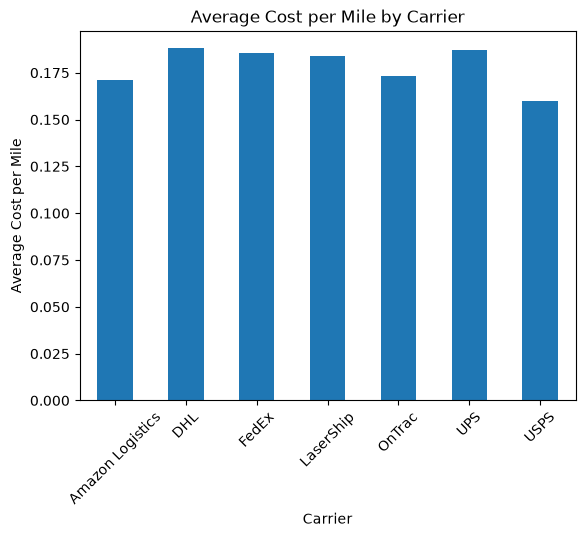

In [47]:
cost_per_mile_by_carrier.plot(kind="bar")

plt.title("Average Cost per Mile by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Cost per Mile")
plt.xticks(rotation=45)

plt.show()

In [48]:
carrier_status = pd.crosstab(
    df["Carrier"],
    df["Status"]
)

print(carrier_status)

Status            Delayed  Delivered  In Transit  Lost  Returned
Carrier                                                         
Amazon Logistics       34        217           8    12         3
DHL                    39        231           8     1         2
FedEx                  26        244          12     6         7
LaserShip              26        248          13    10         6
OnTrac                 29        248          11     4         7
UPS                    24        221           8     0         3
USPS                   21        239          16    12         4


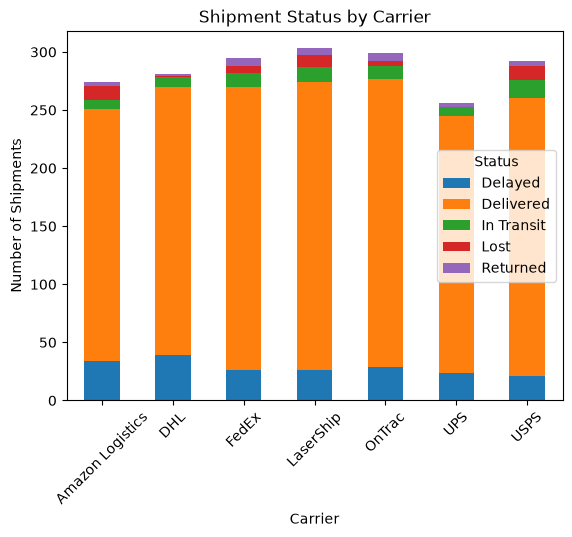

In [49]:
carrier_status.plot(kind="bar", stacked=True)

plt.title("Shipment Status by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.show()

In [50]:
warehouse_status = pd.crosstab(
    df["Origin_Warehouse"],
    df["Status"]
)

print(warehouse_status)

Status            Delayed  Delivered  In Transit  Lost  Returned
Origin_Warehouse                                                
Warehouse_ATL          22        163          10     9         3
Warehouse_BOS          17        161           7     6         1
Warehouse_CHI          21        169           3     2         2
Warehouse_DEN          16        166           8     4         2
Warehouse_HOU          25        169           7     5         6
Warehouse_LA           23        182          10     3         2
Warehouse_MIA          23        157          12     6         3
Warehouse_NYC          10        151           5     3         1
Warehouse_SEA          18        161           5     1         5
Warehouse_SF           24        169           9     6         7


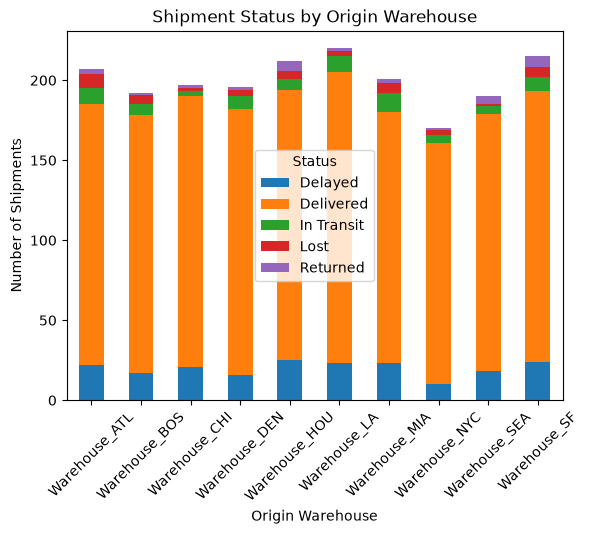

In [51]:
warehouse_status.plot(kind="bar", stacked=True)

plt.title("Shipment Status by Origin Warehouse")
plt.xlabel("Origin Warehouse")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.show()

In [52]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Shipments",
        "Delivered Shipments",
        "Delayed Shipments",
        "Delivery Rate (%)",
        "Delay Rate (%)",
        "Average Transit Days",
        "Average Shipping Cost",
        "Average Weight (kg)",
        "Average Cost per Mile"
    ],
    "Value": [
        total_shipments,
        delivered_shipments,
        delayed_shipments,
        round(delivery_rate, 2),
        round(delay_rate, 2),
        round(average_transit_days, 2),
        round(average_cost, 2),
        round(df["Weight_kg"].mean(), 2),
        round(df["Cost_per_Mile"].mean(), 4)
    ]
})

print(kpi_summary)

                     KPI      Value
0        Total Shipments  2000.0000
1    Delivered Shipments  1648.0000
2      Delayed Shipments   199.0000
3      Delivery Rate (%)    82.4000
4         Delay Rate (%)     9.9500
5   Average Transit Days     4.1800
6  Average Shipping Cost   205.1600
7    Average Weight (kg)    30.1800
8  Average Cost per Mile     0.1783


In [53]:
kpi_summary

,KPI,Value
0,Total Shipments,2000.0000
1,Delivered Shipments,1648.0000
2,Delayed Shipments,199.0000
3,Delivery Rate (%),82.4000
4,Delay Rate (%),9.9500
5,Average Transit Days,4.1800
6,Average Shipping Cost,205.1600
7,Average Weight (kg),30.1800
8,Average Cost per Mile,0.1783


In [54]:
numeric_columns = [
    "Weight_kg",
    "Cost",
    "Distance_miles",
    "Transit_Days",
    "Cost_per_Mile"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix.round(2))

                Weight_kg  Cost  Distance_miles  Transit_Days  Cost_per_Mile
Weight_kg            1.00  0.02           -0.01         -0.01           0.06
Cost                 0.02  1.00            0.44          0.34           0.60
Distance_miles      -0.01  0.44            1.00          0.76          -0.27
Transit_Days        -0.01  0.34            0.76          1.00          -0.18
Cost_per_Mile        0.06  0.60           -0.27         -0.18           1.00


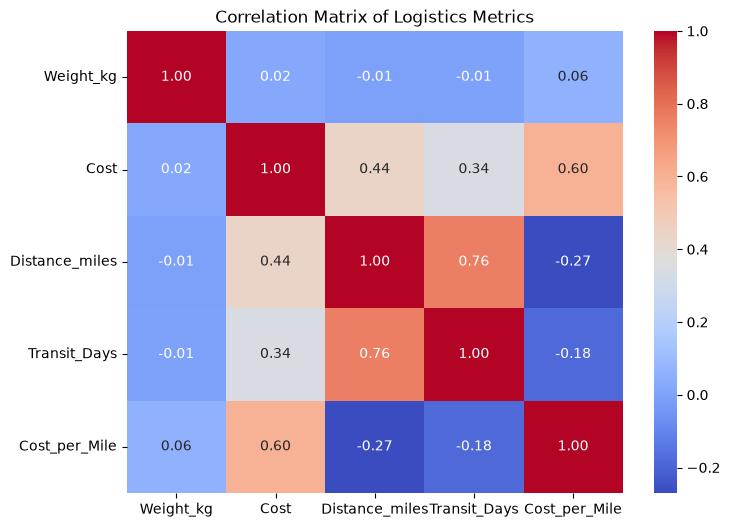

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Logistics Metrics")

plt.show()

In [56]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Shipment_ID                 0
Origin_Warehouse            0
Destination                 0
Carrier                     0
Shipment_Date               0
Delivery_Date              32
Weight_kg                   0
Cost                       41
Status                      0
Distance_miles              0
Transit_Days                0
Calculated_Transit_Days    32
Shipment_Month              0
Cost_per_Mile              41
dtype: int64


In [57]:
duplicate_shipments = df["Shipment_ID"].duplicated().sum()

print("Duplicate Shipment IDs:", duplicate_shipments)

Duplicate Shipment IDs: 0


In [58]:
print("Zero or negative distance:",
      (df["Distance_miles"] <= 0).sum())

print("Zero or negative weight:",
      (df["Weight_kg"] <= 0).sum())

print("Zero or negative cost:",
      (df["Cost"] <= 0).sum())

print("Negative transit days:",
      (df["Transit_Days"] < 0).sum())

Zero or negative distance: 0
Zero or negative weight: 1
Zero or negative cost: 0
Negative transit days: 0


In [59]:
print("Shipment Status Categories:")
print(df["Status"].unique())

Shipment Status Categories:
<ArrowStringArray>
['Delivered', 'Delayed', 'Lost', 'In Transit', 'Returned']
Length: 5, dtype: str


# Final Business Insights

## Logistics Data Analysis – Business Insights

Based on the analysis performed on the shipment dataset, the following business insights were identified:

### 1. Shipment Performance
- The overall delivery and delay rates were calculated to understand shipment performance.
- Shipment status distribution was analyzed to identify the proportion of delivered and delayed shipments.

### 2. Carrier Performance
- Shipment volume, average transit time, delay rate, and average shipping cost were compared across carriers.
- This comparison helps identify carriers that may require further operational review.

### 3. Warehouse Performance
- Origin warehouses were analyzed based on shipment volume, transit time, and delay rate.
- Warehouses with relatively higher delay rates can be investigated for possible operational issues.

### 4. Destination Performance
- Destinations were compared using shipment volume, average transit time, and delay rate.
- Destinations with longer transit times or higher delay rates may require route-level investigation.

### 5. Cost and Shipment Weight
- The relationship between shipment weight and shipping cost was analyzed.
- Average shipping cost and cost per mile were calculated to understand transportation efficiency.

### 6. Distance and Transit Time
- The relationship between transportation distance and transit time was analyzed.
- This helps understand whether longer routes are associated with longer delivery times.

### 7. Monthly Trends
- Monthly shipment volume and delay rates were analyzed.
- Monthly trends can help identify periods with higher shipment activity or increased delays.

## Conclusion

This analysis provides a basic operational view of logistics shipment performance. The results can support further investigation into carrier performance, warehouse operations, transportation costs, routes, and delivery delays.

The analysis is based on the available shipment dataset and should be validated with larger and more detailed operational data before making business decisions.

In [60]:
# Step 25: Generate actual business insights

print("===== FINAL BUSINESS INSIGHTS =====\n")

# Overall performance
print("1. Overall Shipment Performance")
print("Total Shipments:", total_shipments)
print("Delivered Shipments:", delivered_shipments)
print("Delayed Shipments:", delayed_shipments)
print("Delivery Rate:", round(delivery_rate, 2), "%")
print("Delay Rate:", round(delay_rate, 2), "%")
print("Average Transit Days:", round(average_transit_days, 2))
print("Average Shipping Cost:", round(average_cost, 2))

# Best and worst carrier by delay rate
best_carrier = carrier_delay_rate.idxmin()
worst_carrier = carrier_delay_rate.idxmax()

print("\n2. Carrier Performance")
print("Lowest Delay Rate Carrier:", best_carrier,
      "-", round(carrier_delay_rate.min(), 2), "%")
print("Highest Delay Rate Carrier:", worst_carrier,
      "-", round(carrier_delay_rate.max(), 2), "%")

# Warehouse performance
best_warehouse = warehouse_delay_rate.idxmin()
worst_warehouse = warehouse_delay_rate.idxmax()

print("\n3. Warehouse Performance")
print("Lowest Delay Rate Warehouse:", best_warehouse,
      "-", round(warehouse_delay_rate.min(), 2), "%")
print("Highest Delay Rate Warehouse:", worst_warehouse,
      "-", round(warehouse_delay_rate.max(), 2), "%")

# Destination performance
best_destination = destination_delay_rate.idxmin()
worst_destination = destination_delay_rate.idxmax()

print("\n4. Destination Performance")
print("Lowest Delay Rate Destination:", best_destination,
      "-", round(destination_delay_rate.min(), 2), "%")
print("Highest Delay Rate Destination:", worst_destination,
      "-", round(destination_delay_rate.max(), 2), "%")

# Cost and weight
print("\n5. Cost and Shipment Weight")
print("Average Weight:", round(df["Weight_kg"].mean(), 2), "kg")
print("Average Cost per Mile:", round(df["Cost_per_Mile"].mean(), 4))

# Correlations
print("\n6. Relationships Between Metrics")
print("Weight vs Cost Correlation:", round(correlation, 2))
print("Distance vs Transit Correlation:",
      round(distance_transit_correlation, 2))

===== FINAL BUSINESS INSIGHTS =====

1. Overall Shipment Performance
Total Shipments: 2000
Delivered Shipments: 1648
Delayed Shipments: 199
Delivery Rate: 82.4 %
Delay Rate: 9.95 %
Average Transit Days: 4.18
Average Shipping Cost: 205.16

2. Carrier Performance
Lowest Delay Rate Carrier: USPS - 7.19 %
Highest Delay Rate Carrier: DHL - 13.88 %

3. Warehouse Performance
Lowest Delay Rate Warehouse: Warehouse_NYC - 5.88 %
Highest Delay Rate Warehouse: Warehouse_HOU - 11.79 %

4. Destination Performance
Lowest Delay Rate Destination: Miami - 6.5 %
Highest Delay Rate Destination: Boston - 16.81 %

5. Cost and Shipment Weight
Average Weight: 30.18 kg
Average Cost per Mile: 0.1783

6. Relationships Between Metrics
Weight vs Cost Correlation: 0.02
Distance vs Transit Correlation: 0.76


# Final Business Insights

## 1. Overall Shipment Performance

* The dataset contains **2,000 shipments**.
* **1,648 shipments** were delivered, giving a delivery rate of **82.40%**.
* **199 shipments** were marked as delayed, representing a delay rate of **9.95%**.
* The average transit time was **4.18 days**.
* The average shipping cost was **205.16**.

## 2. Carrier Performance

* **USPS** had the lowest observed delay rate at **7.19%**.
* **DHL** had the highest observed delay rate at **13.88%**.
* Carrier-level delay rates can be used to identify areas requiring further operational investigation.

## 3. Warehouse Performance

* **Warehouse_NYC** had the lowest observed delay rate at **5.88%**.
* **Warehouse_HOU** had the highest observed delay rate at **11.79%**.
* Differences between warehouses suggest that warehouse-level operational factors may be worth investigating.

## 4. Destination Performance

* **Miami** had the lowest observed delay rate at **6.50%**.
* **Boston** had the highest observed delay rate at **16.81%**.
* Destinations with higher delay rates may require further analysis of routes, transportation conditions, and delivery operations.

## 5. Cost and Shipment Weight

* The average shipment weight was **30.18 kg**.
* The average cost per mile was **0.1783**.
* The correlation between shipment weight and shipping cost was **0.02**, indicating very little linear relationship between these two variables in this dataset.

## 6. Distance and Transit Time

* The correlation between distance and transit days was **0.76**.
* This indicates a relatively strong positive linear relationship: shipments covering longer distances generally tend to have longer transit times.
* Correlation shows association, not causation.

## 7. Key Operational Areas for Further Investigation

Based on the analysis, the following areas can be investigated further:

* Reasons for higher delay rates for specific carriers.
* Operational differences between warehouses.
* Reasons for higher delays at particular destinations.
* Factors affecting shipping costs beyond shipment weight.
* Routes where long distance is associated with unusually high transit times.

## Conclusion

The analysis provides an overview of shipment performance, carrier performance, warehouse performance, destination performance, transportation cost, and transit time.

The results indicate an overall delivery rate of **82.40%** and a delay rate of **9.95%**. The strong positive relationship between distance and transit time is an important observation for transportation planning.

These findings are based on the available dataset and should be validated with additional operational information before being used for real-world business decisions.


# Business Recommendations

Based on the logistics shipment analysis, the following recommendations can be considered for further operational improvement:

## 1. Investigate Carrier Delay Performance

DHL recorded the highest observed delay rate at **13.88%**, while USPS recorded the lowest at **7.19%**.

The business can investigate the reasons for differences in carrier performance, such as route allocation, transportation capacity, or handling processes.

## 2. Review Warehouse Operations

Warehouse_HOU recorded the highest observed delay rate at **11.79%**, while Warehouse_NYC recorded the lowest at **5.88%**.

Warehouse-level processes can be reviewed to identify factors that may contribute to shipment delays.

## 3. Investigate High-Delay Destinations

Boston recorded the highest observed destination delay rate at **16.81%**, while Miami recorded the lowest at **6.50%**.

Routes and transportation conditions associated with higher-delay destinations can be analyzed in greater detail.

## 4. Improve Long-Distance Route Planning

The correlation between distance and transit days was **0.76**, showing a relatively strong positive linear relationship.

Long-distance shipments can therefore be monitored carefully during planning, with appropriate transit-time expectations and route monitoring.

## 5. Monitor Shipping Cost Efficiency

The average cost per mile was **0.1783**.

Cost per mile can be monitored by carrier, route, warehouse, and destination to identify unusual cost patterns and opportunities for further analysis.

## 6. Analyze Additional Cost Drivers

The correlation between shipment weight and cost was only **0.02**.

This suggests that shipment weight alone does not explain much of the variation in shipping cost in this dataset. Other factors such as distance, carrier, destination, route, and service characteristics should be investigated.

## 7. Build a Regular Logistics Dashboard

A regular dashboard can be developed to monitor:

* Delivery rate
* Delay rate
* Average transit days
* Average shipping cost
* Carrier performance
* Warehouse performance
* Destination performance
* Monthly shipment volume
* Cost per mile

This would help stakeholders monitor logistics performance and identify areas requiring further investigation.

## Recommendation Summary

The analysis suggests that logistics performance can be monitored more effectively by combining **carrier, warehouse, destination, distance, transit-time, and cost-level analysis** rather than relying on a single KPI.
